# Heart Disease Prediction
# Machine Learning (ML) Project

Predicting the presence of heart disease using the UCI Heart Disease dataset. Comparing Logistic Regression, Random Forest and XGBoost Models.

## 1. Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

%matplotlib inline

## 2. Load & Explore Data

In [5]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

Shape: (303, 14)

Data types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## 3. Data Cleaning

In [8]:
# Confirm target is binary
print("Target values:", df['target'].unique())
print(df['target'].value_counts())

Target values: [1 0]
target
1    165
0    138
Name: count, dtype: int64


In [9]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 4. Exploratory Data Analysis (EDA)

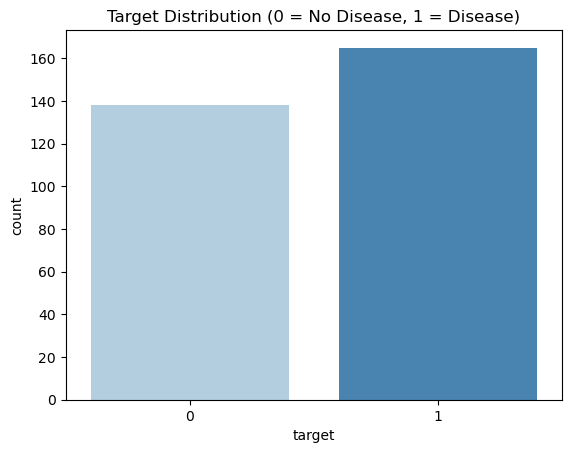

target
1    165
0    138
Name: count, dtype: int64


In [11]:
sns.countplot(x='target', data=df, hue='target', palette='Blues', legend=False)
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
plt.show()
print(df['target'].value_counts())

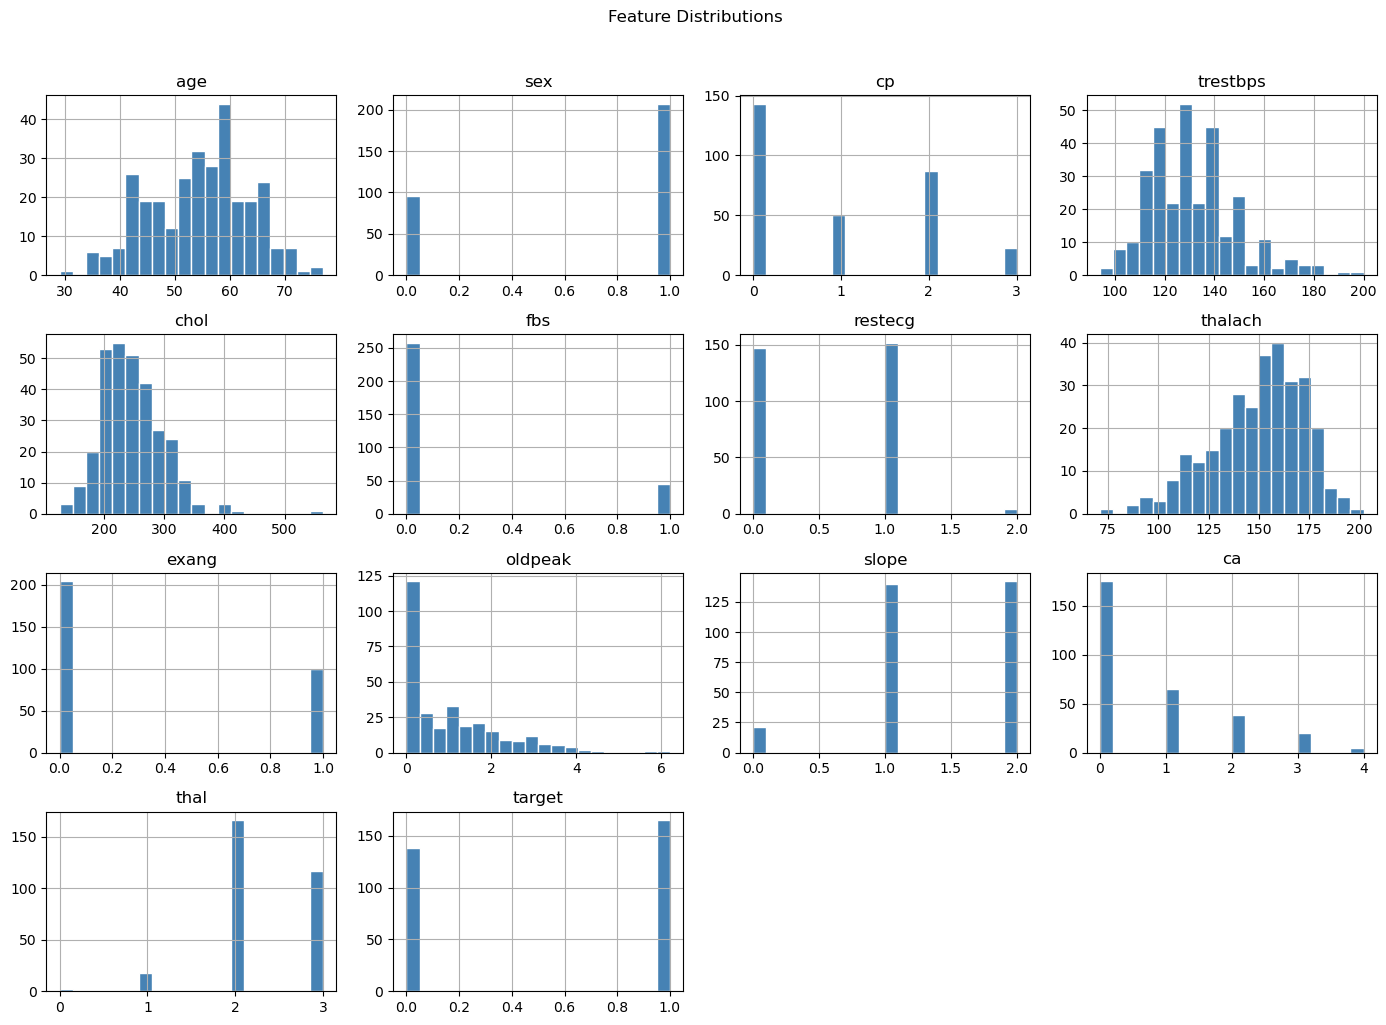

In [12]:
df.hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

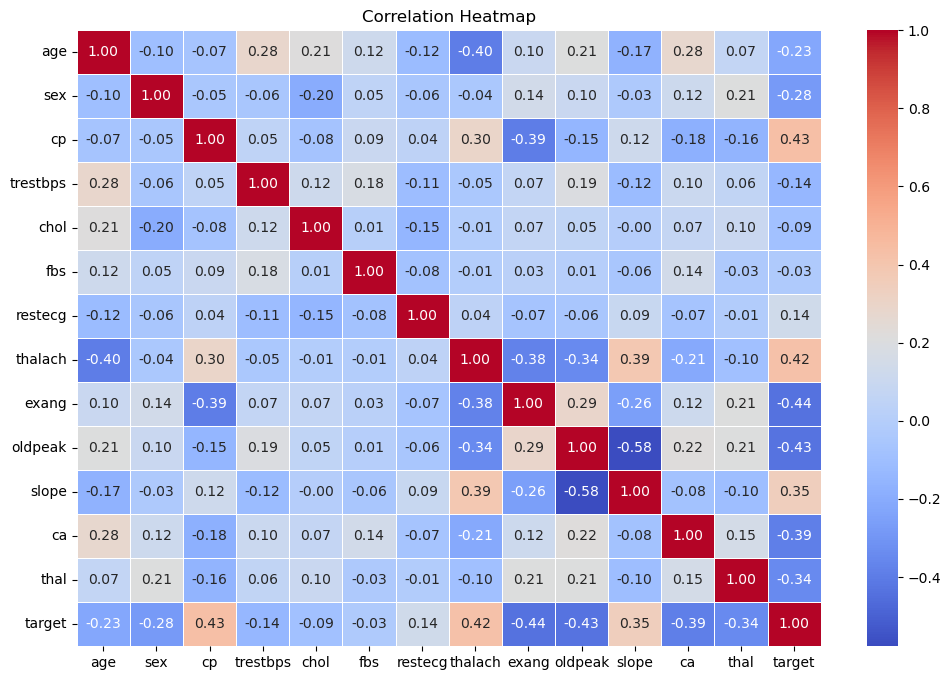

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 5. Preprocessing

Splitting into train/test sets and scaling continuous features.

In [15]:
X = df.drop('target', axis=1)
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (242, 13)
Test size:  (61, 13)


In [17]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])

print("Scaling done ✓")

Scaling done ✓


## 6. Model Training

Training and comparing Logistic Regression, Random Forest, and XGBoost.

In [19]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

print("All models trained ✓")

All models trained ✓


In [20]:
models = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb}

for name, model in models.items():
    acc = model.score(X_test, y_test)
    print(f"{name:25s} → Accuracy: {acc:.4f}")

Logistic Regression       → Accuracy: 0.8033
Random Forest             → Accuracy: 0.8361
XGBoost                   → Accuracy: 0.8033


In [21]:
for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print('='*45)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))


  Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.86      0.68      0.76        28
     Disease       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


  Random Forest
              precision    recall  f1-score   support

  No Disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61


  XGBoost
              precision    recall  f1-score   support

  No Disease       0.90      0.64      0.75        28
     Disease       0.76      0.94      0.84        33

    accuracy                           0.80        61
   macro avg       0.83      0.79      0.79        61
weighted avg       0.82

# 7. Evaluation & Results

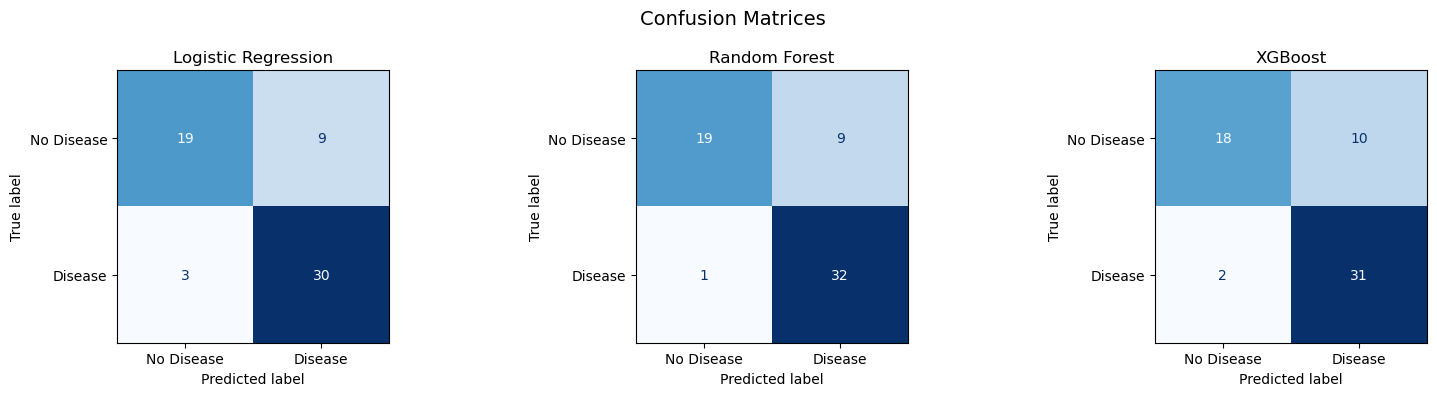

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

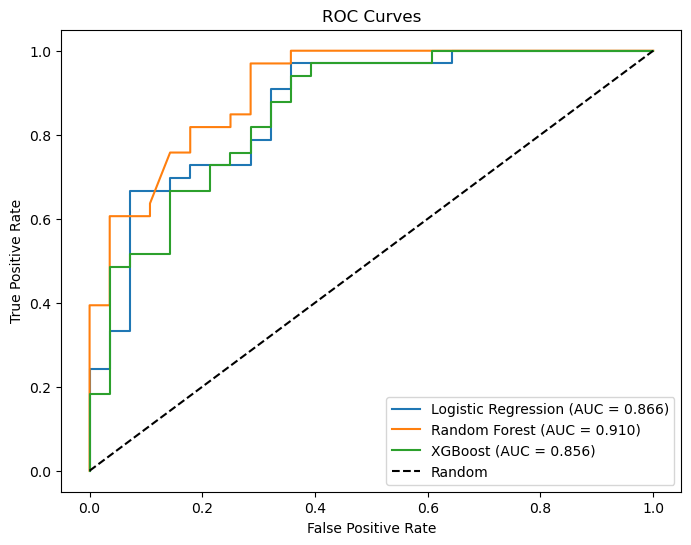

In [24]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

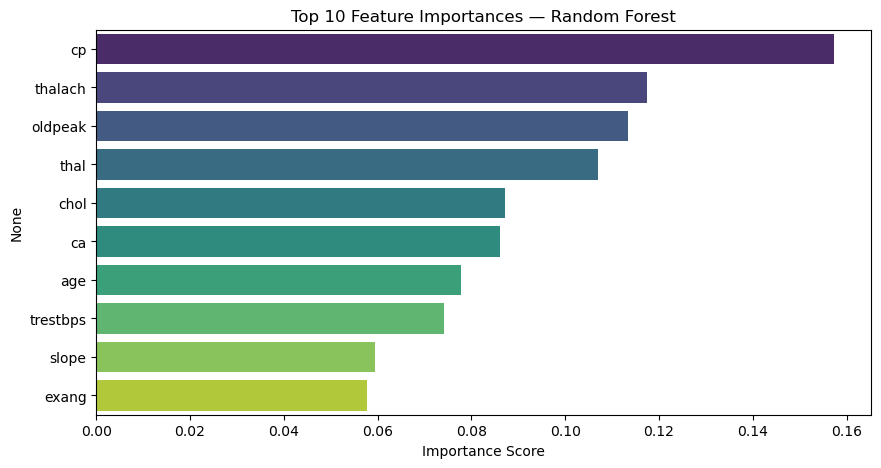

In [25]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [26]:
summary = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    summary.append({
        'Model'   : name,
        'Accuracy': round(model.score(X_test, y_test), 4),
        'ROC-AUC' : round(roc_auc_score(y_test, y_prob), 4)
    })

pd.DataFrame(summary).sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,ROC-AUC
1,Random Forest,0.8361,0.9102
0,Logistic Regression,0.8033,0.8658
2,XGBoost,0.8033,0.8561


## 9. Hyperparameter Tuning (GridSearchCV)

Finding the best parameters for Random Forest to improve accuracy.

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best ROC-AUC score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best ROC-AUC score: 0.917


In [29]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Results:")
print(f"  Accuracy : {round(best_rf.score(X_test, y_test), 4)}")
print(f"  ROC-AUC  : {round(roc_auc_score(y_test, y_prob_tuned), 4)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

Tuned Random Forest Results:
  Accuracy : 0.8033
  ROC-AUC  : 0.9091

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.94      0.61      0.74        28
     Disease       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



## 10. Live Prediction
Enter a patient's details and get an instant heart disease prediction.

In [31]:
def predict_patient(age, sex, cp, trestbps, chol, fbs,
                    restecg, thalach, exang, oldpeak, slope, ca, thal):

    # Create dataframe from input
    patient = pd.DataFrame([{
        'age': age, 'sex': sex, 'cp': cp, 'trestbps': trestbps,
        'chol': chol, 'fbs': fbs, 'restecg': restecg, 'thalach': thalach,
        'exang': exang, 'oldpeak': oldpeak, 'slope': slope, 'ca': ca, 'thal': thal
    }])

    # Scale continuous columns
    patient[continuous_cols] = scaler.transform(patient[continuous_cols])

    # Predict
    prediction = best_rf.predict(patient)[0]
    probability = best_rf.predict_proba(patient)[0][1]

    print("=" * 40)
    print("        PREDICTION RESULT")
    print("=" * 40)
    if prediction == 1:
        print(f"  ⚠️  HEART DISEASE DETECTED")
    else:
        print(f"  ✅  NO HEART DISEASE DETECTED")
    print(f"  Probability of disease: {round(probability * 100, 1)}%")
    print("=" * 40)

In [32]:
# Test with a sample patient
# Modify these values to test different patients
predict_patient(
    age=55,
    sex=1,        # 1 = Male, 0 = Female
    cp=2,         # Chest pain type (0-3)
    trestbps=130, # Resting blood pressure
    chol=250,     # Cholesterol
    fbs=0,        # Fasting blood sugar > 120mg (1=yes, 0=no)
    restecg=1,    # Resting ECG (0-2)
    thalach=150,  # Max heart rate
    exang=0,      # Exercise induced angina (1=yes, 0=no)
    oldpeak=1.5,  # ST depression
    slope=1,      # Slope of ST segment (0-2)
    ca=0,         # Number of major vessels (0-4)
    thal=2        # Thalassemia (0-3)
)

        PREDICTION RESULT
  ⚠️  HEART DISEASE DETECTED
  Probability of disease: 79.2%


## 11. Save & Export Model
Saving the trained model for future use without retraining.

In [34]:
import joblib

# Save the best model and scaler
joblib.dump(best_rf, 'heart_disease_model.pkl')
joblib.dump(scaler,  'scaler.pkl')

print("Model saved as  → heart_disease_model.pkl ✓")
print("Scaler saved as → scaler.pkl ✓")

Model saved as  → heart_disease_model.pkl ✓
Scaler saved as → scaler.pkl ✓


In [35]:
# Test loading the saved model back
loaded_model  = joblib.load('heart_disease_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Verify it works
test_acc = loaded_model.score(X_test, y_test)
print(f"Loaded model accuracy: {round(test_acc, 4)} ✓")
print("Model is ready to use anytime without retraining!")

Loaded model accuracy: 0.8033 ✓
Model is ready to use anytime without retraining!
